# Chọn mức tin cậy — 70% · 80% · 90%

## Câu hỏi

Khoảng dự đoán hiện tại là **±30,11%** ở mức tin cậy **90%**. Nhiều người thấy rộng. Hạ xuống
**80%** hoặc **70%** thì hẹp bao nhiêu, và **đánh đổi cái gì**?

## Hai điều phải nắm trước

> **Mức tin cậy là lựa chọn KINH DOANH, không phải lựa chọn kỹ thuật.**

Không có mức nào "đúng". Chọn mức nào là trả lời câu: *sai bao nhiêu lần trong 10 thì chấp nhận
được?* Notebook này đưa số để quyết định, không tự quyết thay.

> **Hạ mức tin cậy KHÔNG làm model tốt hơn.**

Sai số của model không đổi. Ta chỉ **hứa ít hơn** — khoảng hẹp lại vì bao ít trường hợp hơn.

⚠️ Mức tin cậy ảnh hưởng cách **báo cáo** khoảng, nhưng **Tầng 3 không dùng khoảng** — nó lấy tích
phân trên **toàn bộ phân phối**. Xem Phần 5.

---

| Phần | Câu hỏi | Hình |
|---|---|---|
| 1 | Quét toàn dải 50% → 99% | `TC1` |
| 2 | So trực tiếp 3 mức | `TC2` |
| 3 | Hạ mức có làm coverage điều kiện xấu đi không? | `TC3` |
| 4 | Trên chuyến cụ thể thì khác nhau thế nào | `TC4` |
| 5 | Ảnh hưởng xuống Tầng 3 (quyết định giá) | — |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

cal = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
tes = pd.read_parquet(EVAL / "uq_pred_test.parquet")
sai_cal = ((cal.hybrid_pred - cal.gia_that).abs() / cal.hybrid_pred).values

# ═══ Ba muc dem so sanh ═══
MUCS_SS = [0.70, 0.80, 0.90]
MAU_SS = {0.70: PURPLE, 0.80: ORANGE, 0.90: RED}
GOC = 0.90                      # moc so sanh


def dung_khoang(muc):
    q = np.quantile(sai_cal, muc)
    lo = tes.hybrid_pred * (1 - q)
    hi = tes.hybrid_pred * (1 + q)
    trong = (tes.gia_that >= lo) & (tes.gia_that <= hi)
    return dict(muc=muc, q=q, lo=lo, hi=hi, trong=trong,
                cov=trong.mean(), rong=(hi - lo).mean())


K = {m: dung_khoang(m) for m in MUCS_SS}
G = K[GOC]

print(f"Calibration {len(cal):,} | Test {len(tes):,}")
print()
print(f"{'Muc':>6s} {'q (±%)':>9s} {'Coverage':>10s} {'Do rong TB':>13s} "
      f"{'vs 90%':>9s} {'Truot/1.000':>12s}")
print("-" * 64)
for m in MUCS_SS:
    r = K[m]
    print(f"{m:>5.0%} {r['q']:>9.2%} {r['cov']:>10.2%} {r['rong']:>12,.0f}d "
          f"{r['rong']/G['rong']-1:>+8.1%} {(1-r['cov'])*1000:>12.0f}")

Calibration 615,908 | Test 864,360

   Muc    q (±%)   Coverage    Do rong TB    vs 90%  Truot/1.000
----------------------------------------------------------------
  70%    18.78%     69.73%       45,320d   -37.6%          303
  80%    23.25%     79.60%       56,118d   -22.7%          204
  90%    30.09%     89.55%       72,630d    +0.0%          104


## 1. Quét toàn dải mức tin cậy

Quan hệ **không tuyến tính** — càng gần 100% thì độ rộng càng bùng nổ, càng xuống thấp thì mỗi
điểm % coverage đổi được càng ít độ rộng.

In [2]:
MUCS = np.array([0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99])
rows = []
for m in MUCS:
    r = dung_khoang(m)
    rows.append({
        "Mức tin cậy": f"{m:.0%}",
        "q (±%)": f"{r['q']:.2%}",
        "Coverage đạt": f"{r['cov']:.2%}",
        "Độ rộng TB (đ)": round(r["rong"]),
        "So với 90%": f"{r['rong']/G['rong']-1:+.1%}",
        "Trượt / 1.000": round((1-r["cov"])*1000),
    })
BANG = pd.DataFrame(rows)


def to_dam(s):
    return ["font-weight:700" if v in ("70%", "80%", "90%") else "" for v in s]


display(BANG.style.apply(to_dam, subset=["Mức tin cậy"]).hide(axis="index"))

Mức tin cậy,q (±%),Coverage đạt,Độ rộng TB (đ),So với 90%,Trượt / 1.000
50%,12.14%,49.73%,29298,-59.7%,503
60%,15.19%,59.70%,36667,-49.5%,403
70%,18.78%,69.73%,45320,-37.6%,303
75%,20.87%,74.70%,50378,-30.6%,253
80%,23.25%,79.60%,56118,-22.7%,204
85%,26.16%,84.53%,63134,-13.1%,155
90%,30.09%,89.55%,72630,+0.0%,104
95%,36.50%,94.63%,88090,+21.3%,54
98%,45.71%,97.82%,110342,+51.9%,22
99%,52.83%,98.89%,127512,+75.6%,11


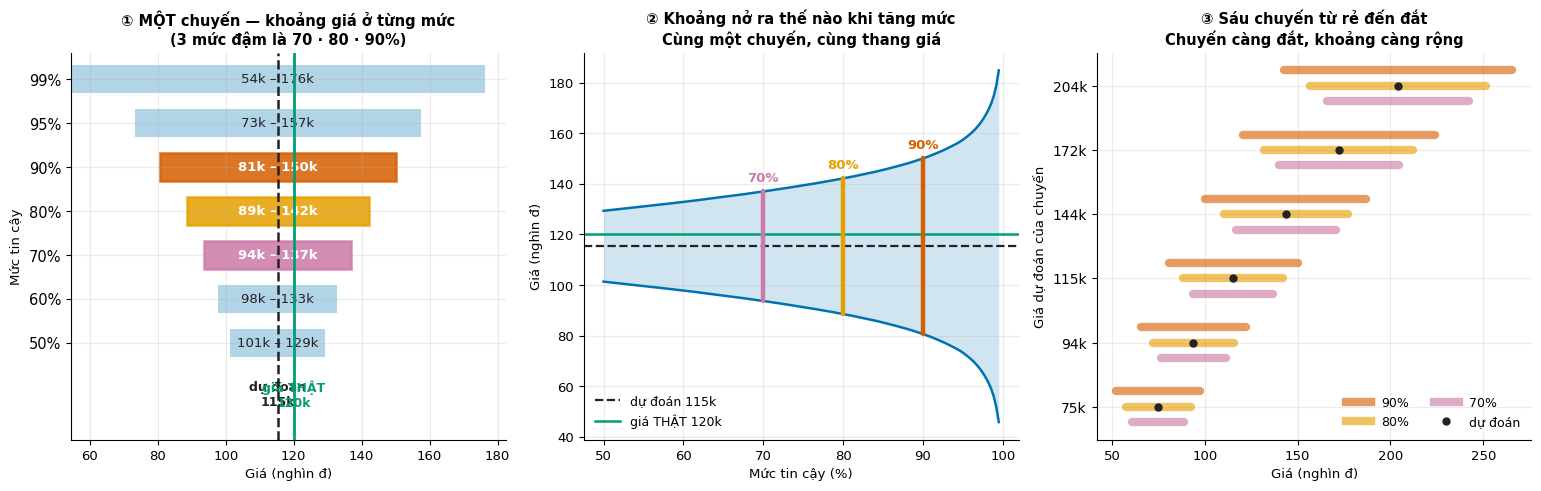

CHUYEN VI DU — gia du doan 115,335d  (gia that 120,000d)
   Muc                 Khoang gia       Do rong
----------------------------------------------------------
  50%      101,335 -     129,334d       27,999d
  60%       97,814 -     132,855d       35,041d
  70%       93,680 -     136,990d       43,310d <<<
  80%       88,520 -     142,149d       53,629d <<<
  90%       80,631 -     150,039d       69,408d <<<
  95%       73,243 -     157,426d       84,183d
  99%       54,407 -     176,263d      121,857d


In [3]:
# ═════════ HINH TC1 — KHOANG GIA THAT theo tung muc tin cay ═════════
MUC_THANG = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

# Chon 1 chuyen co gia du doan gan trung vi de lam vi du
i_vd = int(np.argsort(np.abs(tes.hybrid_pred.values -
                             np.median(tes.hybrid_pred.values)))[0])
p_vd = tes.hybrid_pred.values[i_vd]
that_vd = tes.gia_that.values[i_vd]

fig, ax = plt.subplots(1, 3, figsize=(15.5, 5.0))

# ── (a) MOT chuyen: khoang gia o 7 muc ──
for j, m in enumerate(MUC_THANG):
    q = np.quantile(sai_cal, m)
    lo, hi = p_vd*(1-q), p_vd*(1+q)
    col = MAU_SS.get(m, BLUE)
    dam = m in MUCS_SS
    ax[0].barh(j, (hi-lo)/1000, left=lo/1000, height=.62, color=col,
               alpha=.85 if dam else .30,
               edgecolor=col if dam else "none", linewidth=1.8 if dam else 0)
    ax[0].text((lo+hi)/2000, j, f"{lo/1000:.0f}k – {hi/1000:.0f}k",
               ha="center", va="center", fontsize=9.5,
               fontweight="bold" if dam else "normal",
               color="white" if dam else INK)
# Hai vach moc: du doan va gia that — nhan dat o DAY de khong de tieu de
ax[0].axvline(p_vd/1000, color=INK, lw=1.8, ls="--", zorder=5)
ax[0].axvline(that_vd/1000, color=GREEN, lw=2.0, zorder=5)
ax[0].text(p_vd/1000, -0.85, f"dự đoán\n{p_vd/1000:.0f}k", ha="center", va="top",
           fontsize=9, fontweight="bold", color=INK)
ax[0].text(that_vd/1000, -0.85, f"giá THẬT\n{that_vd/1000:.0f}k", ha="center",
           va="top", fontsize=9, fontweight="bold", color=GREEN)
ax[0].set_yticks(range(len(MUC_THANG)))
ax[0].set_yticklabels([f"{m:.0%}" for m in MUC_THANG], fontsize=10.5)
ax[0].set_ylim(-2.2, len(MUC_THANG)-0.4)
ax[0].set_xlabel("Giá (nghìn đ)"); ax[0].set_ylabel("Mức tin cậy")
ax[0].set_title("① MỘT chuyến — khoảng giá ở từng mức\n(3 mức đậm là 70 · 80 · 90%)",
                fontweight="bold", fontsize=10.5)

# ── (b) Hinh quat: khoang mo rong lien tuc theo muc ──
mm = np.linspace(.50, .995, 160)
qq = np.array([np.quantile(sai_cal, m) for m in mm])
lo_c, hi_c = p_vd*(1-qq)/1000, p_vd*(1+qq)/1000
ax[1].fill_between(mm*100, lo_c, hi_c, color=BLUE, alpha=.18, lw=0)
ax[1].plot(mm*100, lo_c, color=BLUE, lw=1.8)
ax[1].plot(mm*100, hi_c, color=BLUE, lw=1.8)
ax[1].axhline(p_vd/1000, color=INK, lw=1.6, ls="--", label=f"dự đoán {p_vd/1000:.0f}k")
ax[1].axhline(that_vd/1000, color=GREEN, lw=1.8, label=f"giá THẬT {that_vd/1000:.0f}k")
for m in MUCS_SS:
    q = np.quantile(sai_cal, m)
    ax[1].plot([m*100, m*100], [p_vd*(1-q)/1000, p_vd*(1+q)/1000],
               lw=3.2, color=MAU_SS[m], solid_capstyle="round", zorder=4)
    ax[1].text(m*100, p_vd*(1+q)/1000 + 4, f"{m:.0%}", ha="center",
               fontsize=9.5, fontweight="bold", color=MAU_SS[m])
ax[1].set_xlabel("Mức tin cậy (%)"); ax[1].set_ylabel("Giá (nghìn đ)")
ax[1].legend(frameon=False, fontsize=9, loc="lower left")
ax[1].set_title("② Khoảng nở ra thế nào khi tăng mức\nCùng một chuyến, cùng thang giá",
                fontweight="bold", fontsize=10.5)

# ── (c) Sau chuyen tu re den dat ──
pct = [10, 25, 50, 75, 90, 97]
moc = np.percentile(tes.hybrid_pred.values, pct)
i_ch = [int(np.argsort(np.abs(tes.hybrid_pred.values - v))[0]) for v in moc]
off = {0.90: .24, 0.80: 0.0, 0.70: -.24}
for k_, i_ in enumerate(i_ch):
    p_ = tes.hybrid_pred.values[i_]
    for m in sorted(MUCS_SS, reverse=True):
        q = np.quantile(sai_cal, m)
        ax[2].plot([p_*(1-q)/1000, p_*(1+q)/1000], [k_+off[m]]*2, lw=6,
                   color=MAU_SS[m], alpha=.62, solid_capstyle="round")
    ax[2].plot(p_/1000, k_, "o", color=INK, ms=5, zorder=5)
for m in sorted(MUCS_SS, reverse=True):
    ax[2].plot([], [], lw=6, color=MAU_SS[m], alpha=.62, label=f"{m:.0%}")
ax[2].plot([], [], "o", color=INK, ms=5, label="dự đoán")
ax[2].set_yticks(range(len(i_ch)))
ax[2].set_yticklabels([f"{tes.hybrid_pred.values[i]/1000:.0f}k" for i in i_ch],
                      fontsize=10)
ax[2].set_xlabel("Giá (nghìn đ)"); ax[2].set_ylabel("Giá dự đoán của chuyến")
ax[2].legend(frameon=False, fontsize=9, ncol=2)
ax[2].set_title("③ Sáu chuyến từ rẻ đến đắt\nChuyến càng đắt, khoảng càng rộng",
                fontweight="bold", fontsize=10.5)

plt.tight_layout(); plt.savefig(HINH / "TC1_khoang_gia_theo_muc.png"); plt.show()

print(f"CHUYEN VI DU — gia du doan {p_vd:,.0f}d  (gia that {that_vd:,.0f}d)")
print("=" * 58)
print(f"{'Muc':>6s} {'Khoang gia':>26s} {'Do rong':>13s}")
print("-" * 58)
for m in MUC_THANG:
    q = np.quantile(sai_cal, m)
    lo, hi = p_vd*(1-q), p_vd*(1+q)
    dau_ = " <<<" if m in MUCS_SS else ""
    print(f"{m:>5.0%} {lo:>12,.0f} - {hi:>11,.0f}d {hi-lo:>12,.0f}d{dau_}")

> **Đọc hình:** cùng một chuyến, cùng một model — chỉ đổi mức tin cậy thì khoảng giá nở ra hay
> co lại bấy nhiêu. Sai số của model **không đổi**; ta chỉ **hứa nhiều hay ít** đi.

Ba panel còn lại đo cái giá phải trả và đường đánh đổi:

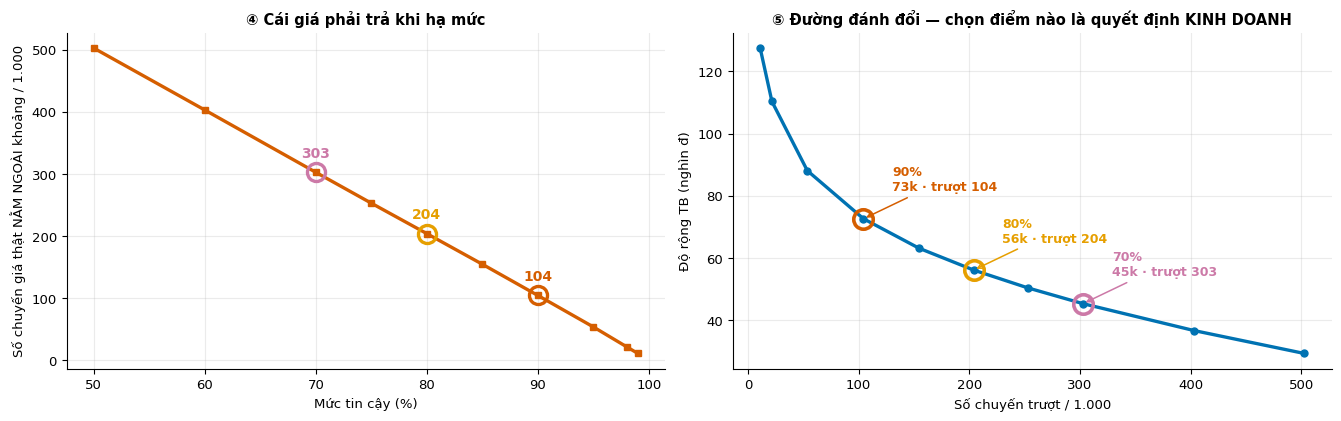

In [4]:
# ═════════ HINH TC1b — cai gia phai tra ═════════
rong = np.array([dung_khoang(m)["rong"] for m in MUCS])
cov = np.array([dung_khoang(m)["cov"] for m in MUCS])

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.3))

ax[0].plot(MUCS*100, (1-cov)*1000, marker="s", lw=2.4, ms=5, color=RED)
for m in MUCS_SS:
    v = (1-K[m]["cov"])*1000
    ax[0].plot(m*100, v, "o", ms=13, mfc="none", mew=2.4, color=MAU_SS[m])
    ax[0].text(m*100, v + 24, f"{v:.0f}", ha="center", fontsize=10,
               fontweight="bold", color=MAU_SS[m])
ax[0].set_xlabel("Mức tin cậy (%)")
ax[0].set_ylabel("Số chuyến giá thật NẰM NGOÀI khoảng / 1.000")
ax[0].set_title("④ Cái giá phải trả khi hạ mức", fontweight="bold", fontsize=10.5)

ax[1].plot((1-cov)*1000, rong/1000, marker="o", lw=2.4, ms=5, color=BLUE, zorder=2)
for m in MUCS_SS:
    r = K[m]
    ax[1].plot((1-r["cov"])*1000, r["rong"]/1000, "o", ms=14, mfc="none", mew=2.6,
               color=MAU_SS[m], zorder=3)
    ax[1].annotate(f"{m:.0%}\n{r['rong']/1000:.0f}k · trượt {(1-r['cov'])*1000:.0f}",
                   xy=((1-r["cov"])*1000, r["rong"]/1000),
                   xytext=((1-r["cov"])*1000+26, r["rong"]/1000+9),
                   fontsize=9, fontweight="bold", color=MAU_SS[m],
                   arrowprops=dict(arrowstyle="->", lw=1.1, color=MAU_SS[m]))
ax[1].set_xlabel("Số chuyến trượt / 1.000"); ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_title("⑤ Đường đánh đổi — chọn điểm nào là quyết định KINH DOANH",
                fontweight="bold", fontsize=10.5)

plt.tight_layout(); plt.savefig(HINH / "TC1b_cai_gia.png"); plt.show()

## 2. So trực tiếp ba mức

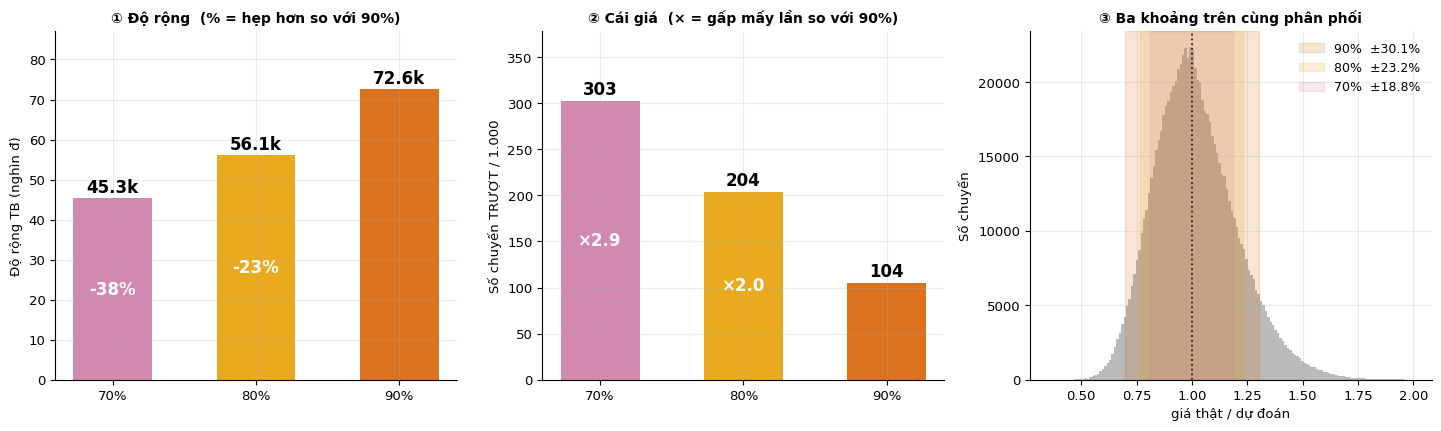

DANH DOI so voi moc 90%
  70% : hep hon 37.6% ( 27,309d)  |  truot gap 2.9 lan (+198/1.000)  |  doi 1 diem coverage = 1.4 nghin d
  80% : hep hon 22.7% ( 16,512d)  |  truot gap 2.0 lan (+100/1.000)  |  doi 1 diem coverage = 1.7 nghin d


In [5]:
# ═════════ HINH TC2 — 70 vs 80 vs 90 ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))
ten3 = [f"{m:.0%}" for m in MUCS_SS]
mau3 = [MAU_SS[m] for m in MUCS_SS]
rong3 = [K[m]["rong"]/1000 for m in MUCS_SS]
truot3 = [(1-K[m]["cov"])*1000 for m in MUCS_SS]

b = ax[0].bar(ten3, rong3, color=mau3, alpha=.88, width=.55)
for bb, v, m in zip(b, rong3, MUCS_SS):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+1.4, f"{v:.1f}k", ha="center",
               fontsize=12, fontweight="bold")
    if m != GOC:
        ax[0].text(bb.get_x()+bb.get_width()/2, v/2,
                   f"{K[m]['rong']/G['rong']-1:+.0%}", ha="center", va="center",
                   fontsize=12, fontweight="bold", color="white")
ax[0].set_ylabel("Độ rộng TB (nghìn đ)"); ax[0].set_ylim(0, max(rong3)*1.2)
ax[0].set_title("① Độ rộng  (% = hẹp hơn so với 90%)", fontweight="bold", fontsize=10)

b2 = ax[1].bar(ten3, truot3, color=mau3, alpha=.88, width=.55)
for bb, v, m in zip(b2, truot3, MUCS_SS):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+7, f"{v:.0f}", ha="center",
               fontsize=12, fontweight="bold")
    if m != GOC:
        ax[1].text(bb.get_x()+bb.get_width()/2, v/2,
                   f"×{(1-K[m]['cov'])/(1-G['cov']):.1f}", ha="center", va="center",
                   fontsize=12, fontweight="bold", color="white")
ax[1].set_ylabel("Số chuyến TRƯỢT / 1.000"); ax[1].set_ylim(0, max(truot3)*1.25)
ax[1].set_title("② Cái giá  (× = gấp mấy lần so với 90%)", fontweight="bold", fontsize=10)

ax[2].hist((tes.gia_that/tes.hybrid_pred).values, bins=150, range=(.35, 2.0),
           color=MUT, alpha=.45, lw=0)
for m in sorted(MUCS_SS, reverse=True):
    ax[2].axvspan(1-K[m]["q"], 1+K[m]["q"], color=MAU_SS[m], alpha=.16,
                  label=f"{m:.0%}  ±{K[m]['q']:.1%}")
ax[2].axvline(1, color=INK, lw=1.3, ls=":")
ax[2].set_xlabel("giá thật / dự đoán"); ax[2].set_ylabel("Số chuyến")
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Ba khoảng trên cùng phân phối", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "TC2_70_80_90.png"); plt.show()

print("=" * 68)
print("DANH DOI so voi moc 90%")
print("=" * 68)
for m in MUCS_SS:
    if m == GOC:
        continue
    r = K[m]
    d_cov = (G["cov"] - r["cov"]) * 100
    print(f"  {m:.0%} : hep hon {abs(r['rong']/G['rong']-1)*100:4.1f}% "
          f"({G['rong']-r['rong']:>7,.0f}d)  |  "
          f"truot gap {(1-r['cov'])/(1-G['cov']):.1f} lan "
          f"(+{(1-r['cov'])*1000-(1-G['cov'])*1000:.0f}/1.000)  |  "
          f"doi 1 diem coverage = {(G['rong']-r['rong'])/1000/d_cov:.1f} nghin d")

## 3. Hạ mức có làm coverage **điều kiện** xấu đi không?

Coverage tổng đạt danh mục là một chuyện. Câu hỏi thật: hạ mức thì **nhóm nào bị thiệt nhiều hơn**?
Nếu độ lệch giữa các nhóm phình ra thì hạ mức tốn thêm một cái giá **ẩn**.

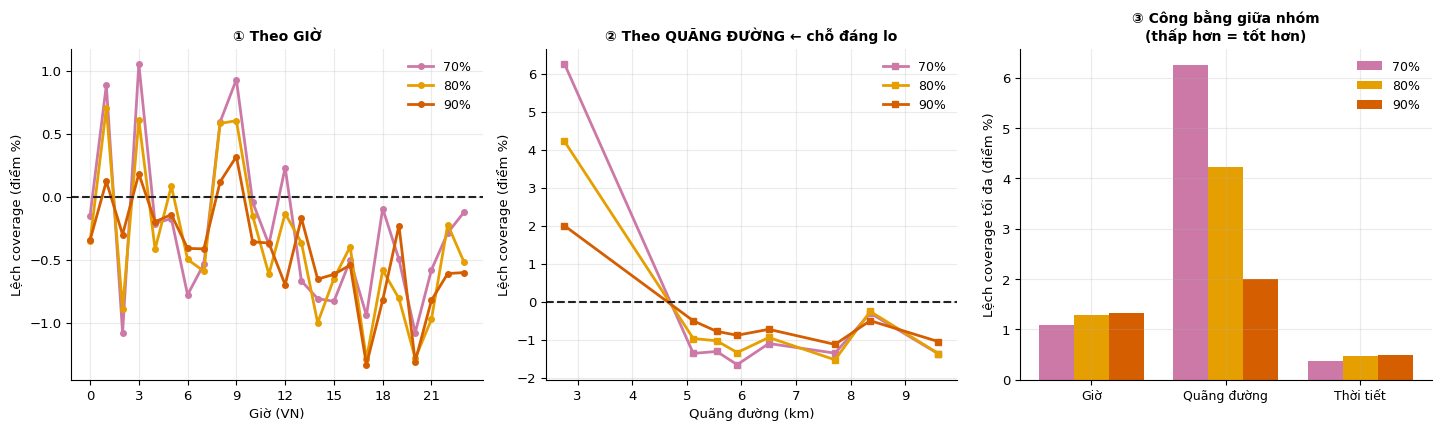

,Mức,Giờ,Quãng đường,Thời tiết,XẤU NHẤT
0,70%,1.08,6.26,0.38,6.26
1,80%,1.29,4.22,0.48,4.22
2,90%,1.33,2.00,0.50,2.00



CAI GIA AN cua viec ha muc — lech coverage TOI DA:
   70% -> 6.26 diem  (chieu quang duong: 6.26)
   80% -> 4.22 diem  (chieu quang duong: 4.22)
   90% -> 2.00 diem  (chieu quang duong: 2.00)

=> Cang ha muc, cong bang giua cac nhom quang duong cang xau.
   Neu chon muc thap, NEN dung kem Mondrian (notebook 04) de bu lai.


In [6]:
# ═════════ HINH TC3 — coverage dieu kien ═════════
t = tes.copy()
for m in MUCS_SS:
    t[f"trong_{int(m*100)}"] = K[m]["trong"].values
t["mua"] = t.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
t["nhom_km"] = pd.qcut(t.quote_distance, 8, labels=False, duplicates="drop")

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

for m in MUCS_SS:
    g = t.groupby("gio_vn")[f"trong_{int(m*100)}"].mean()*100
    ax[0].plot(g.index, g.values - m*100, marker="o", lw=2, ms=4,
               color=MAU_SS[m], label=f"{m:.0%}")
ax[0].axhline(0, color=INK, lw=1.5, ls="--")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Lệch coverage (điểm %)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("① Theo GIỜ", fontweight="bold", fontsize=10)

km = t.groupby("nhom_km").quote_distance.median()
for m in MUCS_SS:
    g = t.groupby("nhom_km")[f"trong_{int(m*100)}"].mean()*100
    ax[1].plot(km.values, g.values - m*100, marker="s", lw=2, ms=5,
               color=MAU_SS[m], label=f"{m:.0%}")
ax[1].axhline(0, color=INK, lw=1.5, ls="--")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("② Theo QUÃNG ĐƯỜNG ← chỗ đáng lo", fontweight="bold", fontsize=10)

rows_dk = []
for m in MUCS_SS:
    c = f"trong_{int(m*100)}"
    lg = abs(t.groupby("gio_vn")[c].mean()*100 - m*100).max()
    lk = abs(t.groupby("nhom_km")[c].mean()*100 - m*100).max()
    lt = abs(t.groupby("mua")[c].mean()*100 - m*100).max()
    rows_dk.append({"Mức": f"{m:.0%}", "Giờ": round(lg, 2), "Quãng đường": round(lk, 2),
                    "Thời tiết": round(lt, 2), "XẤU NHẤT": round(max(lg, lk, lt), 2)})
DK = pd.DataFrame(rows_dk)

x = np.arange(3); w = .26
for i, m in enumerate(MUCS_SS):
    ax[2].bar(x + (i-1)*w, DK.iloc[i][["Giờ", "Quãng đường", "Thời tiết"]].values, w,
              color=MAU_SS[m], label=f"{m:.0%}")
ax[2].set_xticks(x); ax[2].set_xticklabels(["Giờ", "Quãng đường", "Thời tiết"], fontsize=9)
ax[2].set_ylabel("Lệch coverage tối đa (điểm %)")
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Công bằng giữa nhóm\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "TC3_coverage_dieu_kien.png"); plt.show()
display(DK)

print("\nCAI GIA AN cua viec ha muc — lech coverage TOI DA:")
for _, r in DK.iterrows():
    print(f"  {r['Mức']:>4s} -> {r['XẤU NHẤT']:.2f} diem  (chieu quang duong: {r['Quãng đường']:.2f})")
print()
print("=> Cang ha muc, cong bang giua cac nhom quang duong cang xau.")
print("   Neu chon muc thap, NEN dung kem Mondrian (notebook 04) de bu lai.")

## 4. Trên chuyến cụ thể thì khác nhau thế nào

Con số trung bình khó hình dung. Đây là khoảng thật cho vài chuyến, tính bằng đồng.

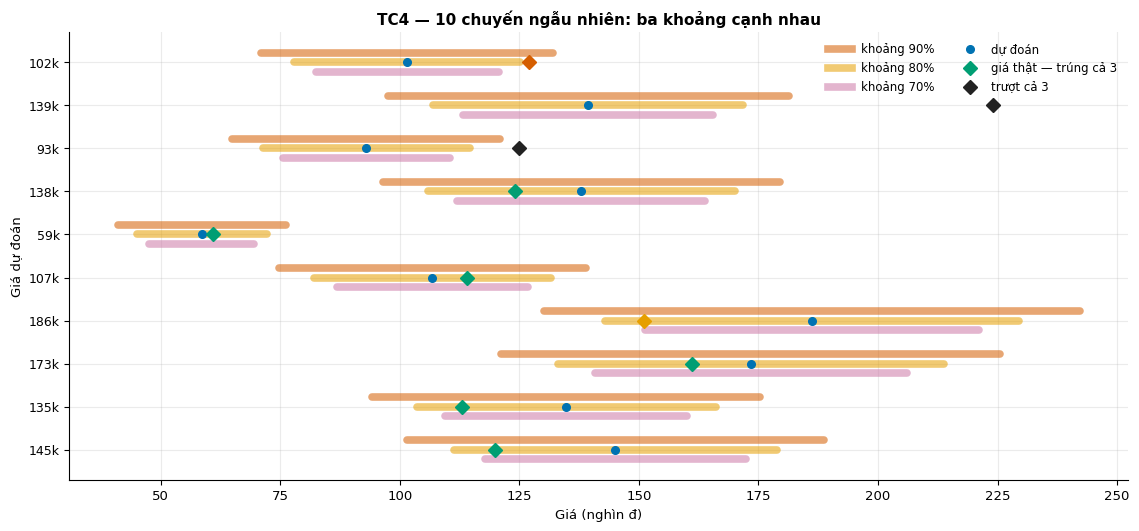

,Dự đoán,Khoảng 70%,Khoảng 80%,Khoảng 90%,Giá thật
0,"145,062đ","117,825 – 172,299","111,336 – 178,788","101,413 – 188,711","120,000đ"
1,"134,827đ","109,512 – 160,142","103,481 – 166,173","94,257 – 175,396","113,000đ"
2,"173,430đ","140,867 – 205,993","133,109 – 213,751","121,245 – 225,615","161,000đ"
3,"186,209đ","151,247 – 221,172","142,917 – 229,502","130,179 – 242,240","151,000đ"
4,"106,825đ","86,767 – 126,882","81,989 – 131,660","74,681 – 138,968","114,000đ"
5,"58,575đ","47,577 – 69,573","44,957 – 72,193","40,950 – 76,200","61,000đ"
6,"137,932đ","112,034 – 163,830","105,864 – 170,000","96,428 – 179,436","124,000đ"
7,"92,955đ","75,502 – 110,408","71,344 – 114,566","64,985 – 120,925","125,000đ"
8,"139,404đ","113,229 – 165,578","106,993 – 171,814","97,457 – 181,350","224,000đ"
9,"101,568đ","82,498 – 120,639","77,955 – 125,182","71,007 – 132,130","127,000đ"


In [7]:
# ═════════ HINH TC4 — chuyen cu the ═════════
rng = np.random.default_rng(7)
n = 10
idx = rng.choice(len(tes), n, replace=False)
s = tes.iloc[idx].reset_index(drop=True)
KH = {m: (s.hybrid_pred*(1-K[m]["q"]), s.hybrid_pred*(1+K[m]["q"])) for m in MUCS_SS}

fig, ax = plt.subplots(figsize=(11.5, 5.4))
off = {0.90: .22, 0.80: 0.0, 0.70: -.22}
for m in sorted(MUCS_SS, reverse=True):
    lo_, hi_ = KH[m]
    for i in range(n):
        ax.plot([lo_[i]/1000, hi_[i]/1000], [i+off[m], i+off[m]], lw=5.5,
                color=MAU_SS[m], alpha=.55, solid_capstyle="round")
for i in range(n):
    ax.plot(s.hybrid_pred[i]/1000, i, "o", color=BLUE, ms=5.5, zorder=4)
    trung = [m for m in MUCS_SS if KH[m][0][i] <= s.gia_that[i] <= KH[m][1][i]]
    c = GREEN if 0.70 in trung else (ORANGE if 0.80 in trung else
                                     (RED if 0.90 in trung else INK))
    ax.plot(s.gia_that[i]/1000, i, "D", ms=7, zorder=5, color=c)
for m in sorted(MUCS_SS, reverse=True):
    ax.plot([], [], lw=5.5, color=MAU_SS[m], alpha=.55, label=f"khoảng {m:.0%}")
ax.plot([], [], "o", color=BLUE, ms=5.5, label="dự đoán")
ax.plot([], [], "D", color=GREEN, ms=7, label="giá thật — trúng cả 3")
ax.plot([], [], "D", color=INK, ms=7, label="trượt cả 3")
ax.set_yticks(range(n))
ax.set_yticklabels([f"{v/1000:.0f}k" for v in s.hybrid_pred], fontsize=9)
ax.set_ylabel("Giá dự đoán"); ax.set_xlabel("Giá (nghìn đ)")
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper right")
ax.set_title("TC4 — 10 chuyến ngẫu nhiên: ba khoảng cạnh nhau",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "TC4_chuyen_cu_the.png"); plt.show()

vd = pd.DataFrame({"Dự đoán": [f"{v:,.0f}đ" for v in s.hybrid_pred]})
for m in MUCS_SS:
    lo_, hi_ = KH[m]
    vd[f"Khoảng {m:.0%}"] = [f"{a:,.0f} – {b:,.0f}" for a, b in zip(lo_, hi_)]
vd["Giá thật"] = [f"{v:,.0f}đ" for v in s.gia_that]
display(vd)

## 5. Ảnh hưởng xuống Tầng 3 — câu trả lời có thể gây bất ngờ

Tầng 3 (quyết định giá) **KHÔNG dùng khoảng tin cậy**. Nó lấy tích phân trên **toàn bộ phân phối**:

$$\mathbb{E}[\Pi(p)] = \int (p - MC)\cdot P(\text{chấp nhận})\cdot f(p_{đt})\, dp_{đt}$$

Phân phối `f` **không đổi** khi ta chọn mức tin cậy khác — mức tin cậy chỉ là cách **cắt** phân
phối đó để báo cáo cho người đọc.

In [8]:
P0, EPS, C_CHINH = 0.50, -2.0, 0.50
R_GRID = np.linspace(0.40, 2.00, 1601)
u_cal = (pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
         .pipe(lambda d: d.gia_that / d.q50)).values
u_luoi = np.quantile(u_cal, np.linspace(0.0005, 0.9995, 2000))


def P_accept(r, eps=EPS, P0=P0):
    b = eps/(1-P0); a = np.log(P0/(1-P0))
    return 1/(1+np.exp(-(a + b*np.log(r))))


def toi_uu(u):
    v = np.array([(r-C_CHINH) * P_accept(r/u).mean() for r in R_GRID])
    return R_GRID[int(np.argmax(v))]


print("GIA TOI UU o Tang 3  (c = 50%, eps = -2.0)")
print("=" * 58)
print(f"  Dung TOAN BO phan phoi  ->  r* = {toi_uu(u_luoi):.4f}   <- DUNG")
print()
print("  Neu ai do chi dung khoang da cat (SAI cach):")
for m in MUCS_SS:
    lo_, hi_ = np.quantile(u_cal, [(1-m)/2, 1-(1-m)/2])
    u_cat = u_luoi[(u_luoi >= lo_) & (u_luoi <= hi_)]
    print(f"    khoang {m:.0%}  ->  r* = {toi_uu(u_cat):.4f}")
print()
print("  => Muc tin cay KHONG anh huong quyet dinh gia,")
print("     vi Tang 3 dung ca phan phoi chu khong dung khoang cat.")
print("     No chi anh huong CACH BAO CAO khoang cho nguoi doc.")

GIA TOI UU o Tang 3  (c = 50%, eps = -2.0)
  Dung TOAN BO phan phoi  ->  r* = 1.0410   <- DUNG

  Neu ai do chi dung khoang da cat (SAI cach):
    khoang 70%  ->  r* = 1.0100
    khoang 80%  ->  r* = 1.0160
    khoang 90%  ->  r* = 1.0250

  => Muc tin cay KHONG anh huong quyet dinh gia,
     vi Tang 3 dung ca phan phoi chu khong dung khoang cat.
     No chi anh huong CACH BAO CAO khoang cho nguoi doc.


## Kết luận

In [9]:
print("╔" + "═"*72 + "╗")
print("║" + " CHON MUC TIN CAY — TONG KET ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print(f"  {'':24s}" + "".join(f"{m:>14.0%}" for m in MUCS_SS))
print("  " + "-"*66)
for ten, lay, fmt in [
        ("q (±%)", lambda r: r["q"], "{:>13.2%}"),
        ("Do rong TB", lambda r: r["rong"], "{:>13,.0f}d"),
        ("Coverage", lambda r: r["cov"], "{:>13.2%}"),
        ("Truot / 1.000 chuyen", lambda r: (1-r["cov"])*1000, "{:>14.0f}")]:
    print(f"  {ten:24s}" + "".join(fmt.format(lay(K[m])) for m in MUCS_SS))
print(f"  {'Lech coverage max':24s}" +
      "".join(f"{DK.iloc[i]['XẤU NHẤT']:>13.2f}d" for i in range(len(MUCS_SS))))
print()
print("  SO VOI MOC 90%:")
for m in MUCS_SS:
    if m == GOC:
        continue
    r = K[m]
    print(f"    {m:.0%} : hep hon {abs(r['rong']/G['rong']-1)*100:4.1f}%  |  "
          f"truot gap {(1-r['cov'])/(1-G['cov']):.1f} lan  |  "
          f"cong bang xau di {DK[DK['Mức']==f'{m:.0%}']['XẤU NHẤT'].iloc[0]/DK[DK['Mức']==f'{GOC:.0%}']['XẤU NHẤT'].iloc[0]:.1f} lan")
print()
print("  ANH HUONG XUONG TANG 3: KHONG. Quyet dinh gia dung ca phan phoi.")
print()
print("─"*74)
print("  KHUYEN NGHI — day la QUYET DINH KINH DOANH, can mentor chot:")
print("    90%  ràng buộc vận hành (chặn báo giá ngoài dải)")
print("    80%  bao cao / tham khao — can bang tot nhat")
print("    70%  chi khi CAN khoang that hep va chap nhan sai ~1/3 lan")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                      CHON MUC TIN CAY — TONG KET                       ║
╚════════════════════════════════════════════════════════════════════════╝

                                     70%           80%           90%
  ------------------------------------------------------------------
  q (±%)                         18.78%       23.25%       30.09%
  Do rong TB                     45,320d       56,118d       72,630d
  Coverage                       69.73%       79.60%       89.55%
  Truot / 1.000 chuyen               303           204           104
  Lech coverage max                6.26d         4.22d         2.00d

  SO VOI MOC 90%:
    70% : hep hon 37.6%  |  truot gap 2.9 lan  |  cong bang xau di 3.1 lan
    80% : hep hon 22.7%  |  truot gap 2.0 lan  |  cong bang xau di 2.1 lan

  ANH HUONG XUONG TANG 3: KHONG. Quyet dinh gia dung ca phan phoi.

───────────────────────────────────────────────────────────

### Ba điều rút ra

**1. Đánh đổi không đối xứng.** Từ 90% xuống 80% đổi được nhiều độ rộng; xuống tiếp 70% thì mỗi
điểm % coverage đổi được **ít độ rộng hơn** — xem `TC1` panel ③, đường cong thoải dần.

**2. Hạ mức có một cái giá ẩn: công bằng giữa nhóm xấu đi.** Độ lệch coverage theo **quãng đường**
phình ra khi hạ mức. Nếu chọn mức thấp, **nên dùng kèm Mondrian** (notebook `04`) để bù lại.

**3. Mức tin cậy KHÔNG ảnh hưởng Tầng 3.** Quyết định giá lấy tích phân trên toàn bộ phân phối,
không dùng khoảng cắt. Đây thuần tuý là câu hỏi về **cách báo cáo**.

### Cách chọn

| Khoảng dùng để | Nên chọn |
|---|---|
| **Ràng buộc vận hành** (chặn báo giá ngoài dải) | **90%** — trượt 1/5 lần đã là quá nhiều cho ràng buộc |
| **Báo cáo / tham khảo** cho người đọc | **80%** — cân bằng tốt nhất |
| Cần khoảng thật hẹp, chấp nhận sai ~1/3 lần | 70% |
| Đầu vào cho Tầng 3 | **Không dùng khoảng** — dùng cả phân phối |

⇒ **Câu hỏi cho mentor:** khoảng dự đoán sẽ được dùng làm gì?

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `TC1_quet_muc_tin_cay` | Quét 50%→99%, đánh dấu 3 mức |
| `TC2_70_80_90` | So trực tiếp 3 mức |
| `TC3_coverage_dieu_kien` | Cái giá ẩn — công bằng giữa nhóm |
| `TC4_chuyen_cu_the` | 10 chuyến thật, 3 khoảng cạnh nhau |

## Liên quan

| File | Vai trò |
|---|---|
| `03_truc_quan_UQ.ipynb` | Cơ chế conformal |
| `04_UQ_theo_quang_duong.ipynb` | Mondrian — bù lại công bằng khi hạ mức |
| `../acceptance/07_chiphi_bien_va_uncertainty.ipynb` | Nơi phân phối được dùng thật |